# Part 2: Iris Analysis & Depth Estimation

Estimate camera-to-eye distance using iris diameter (pinhole camera model) and fit ellipses to the iris shape.

References:
- [MediaPipe Iris](https://github.com/google/mediapipe/blob/master/docs/solutions/iris.md)
- [MediaPipe Iris paper](https://arxiv.org/abs/2006.11341)
- [Ellipse (Wikipedia)](https://en.wikipedia.org/wiki/Ellipse)

In [ ]:
!pip install mediapipe
!wget -O face_landmarker_v2_with_blendshapes.task -q \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [ ]:
from google.colab import files

import cv2
from google.colab.patches import cv2_imshow
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt
import math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from PIL import Image, ImageDraw

In [ ]:
import glob
import re

img_list = glob.glob('./*.png')

def extract_number(item):
    match = re.search(r'\d+', item)
    return int(match.group()) if match else 0

sorted_list = sorted(img_list, key=extract_number)
sorted_list

['./face_1.png',
 './face_2.png',
 './face_3.png',
 './face_4.png',
 './face_5.png',
 './face_6.png',
 './face_7.png',
 './face_8.png',
 './face_9.png',
 './face_11.png',
 './face_12.png',
 './face_13.png',
 './face_14.png',
 './face_21.png',
 './face_22.png',
 './face_23.png',
 './face_24.png',
 './face_31.png',
 './face_32.png']

In [ ]:
base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    num_faces=1
)
detector = vision.FaceLandmarker.create_from_options(options)

### 2.1 Camera-to-Eye Distance Estimation (Pinhole Camera Model)

**Sensor specifications:**
- Pixel scale: 2.8 µm (equal in x and y directions)
- Resolution: FHD (1920×1080)
- Focal length: $(f_x, f_y) = (6\text{mm}, 6\text{mm})$
- Assumption: no lens distortion (rectilinear lens) → pinhole camera model

**Image size on sensor:**

$ \text{ImageSize (mm)} = \text{pixel scale (µm)} \times \text{NumberOfPixels} $

**Distance formula (pinhole model):**

$ D = \frac{f \times \text{RealSize}}{\text{ImageSize}} $

where:
- $f = 6\text{mm}$
- $\text{RealSize} = 24\text{mm}$ (horizontal iris diameter ≈ 11.7±0.5 mm → full eye ~24mm)

Thus:

$ D = \frac{6 \times 24}{0.0028 \times N_{\text{pixels}}} \approx \frac{51439}{N_{\text{pixels}}} \text{ (mm)}$

Only the number of pixels spanning the iris diameter is needed to compute the distance.

In [ ]:
def cal_distance(num_pix):
    """Estimate camera-to-eye distance in mm from iris pixel diameter."""
    return 51439 / num_pix

In [ ]:
def draw_IRIS_on_image(rgb_image, detection_result):
    face_landmarks_list = detection_result.face_landmarks
    annotated_image = np.copy(rgb_image)

    for i, l in enumerate(face_landmarks_list):
        face_landmarks = l
        face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        face_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z)
            for landmark in face_landmarks
        ])
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
                .get_default_face_mesh_iris_connections_style()
        )

    distance = 0
    if detection_result.face_blendshapes != []:
        rightEyeIris = detection_result.face_landmarks[0][473:]
        leftEyeIris = detection_result.face_landmarks[0][468:473]

        r1, r2 = rightEyeIris[1], rightEyeIris[3]
        l1, l2 = leftEyeIris[1], leftEyeIris[3]

        distance_r = math.sqrt(
            (r1.x * annotated_image.shape[1] - r2.x * annotated_image.shape[1]) ** 2 +
            (r1.y * annotated_image.shape[0] - r2.y * annotated_image.shape[0]) ** 2
        )
        distance_l = math.sqrt(
            (l1.x * annotated_image.shape[1] - l2.x * annotated_image.shape[1]) ** 2 +
            (l1.y * annotated_image.shape[0] - l2.y * annotated_image.shape[0]) ** 2
        )
        distance = (distance_r + distance_l) / 2
        distance = cal_distance(int(distance))

    return annotated_image, distance

In [ ]:
def make_IRIS_image(img_name):
    img = mp.Image.create_from_file(img_name)
    detection_result = detector.detect(img)
    landmark_image, d = draw_IRIS_on_image(img.numpy_view()[..., :3], detection_result)

    blink_threshold = 0
    blink = 'eyes not found'
    if detection_result.face_blendshapes != []:
        for category in detection_result.face_blendshapes[0]:
            if 'Blink' in category.category_name:
                blink_threshold += category.score
        if blink_threshold > 1 / 2:
            blink = 'eyes closed'
        else:
            blink = 'eyes opened'

    return landmark_image, blink, d

### Iris Detection & Distance Estimation Results

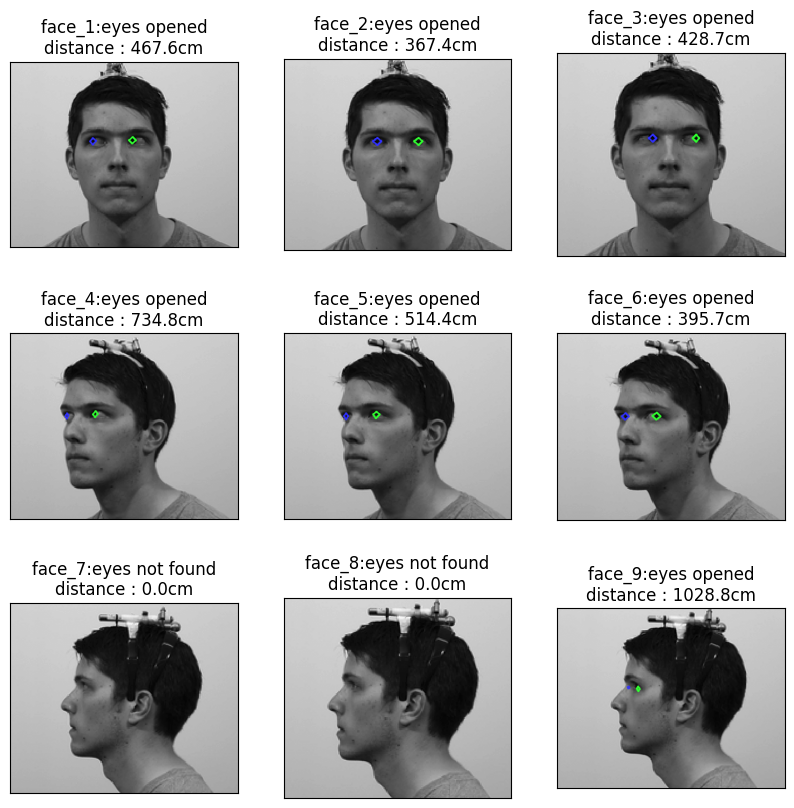

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        img = sorted_list[3*i+j]
        landmark_image, b, d = make_IRIS_image(img)
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}:{b}\ndistance : {np.round(d/10, 1)}cm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

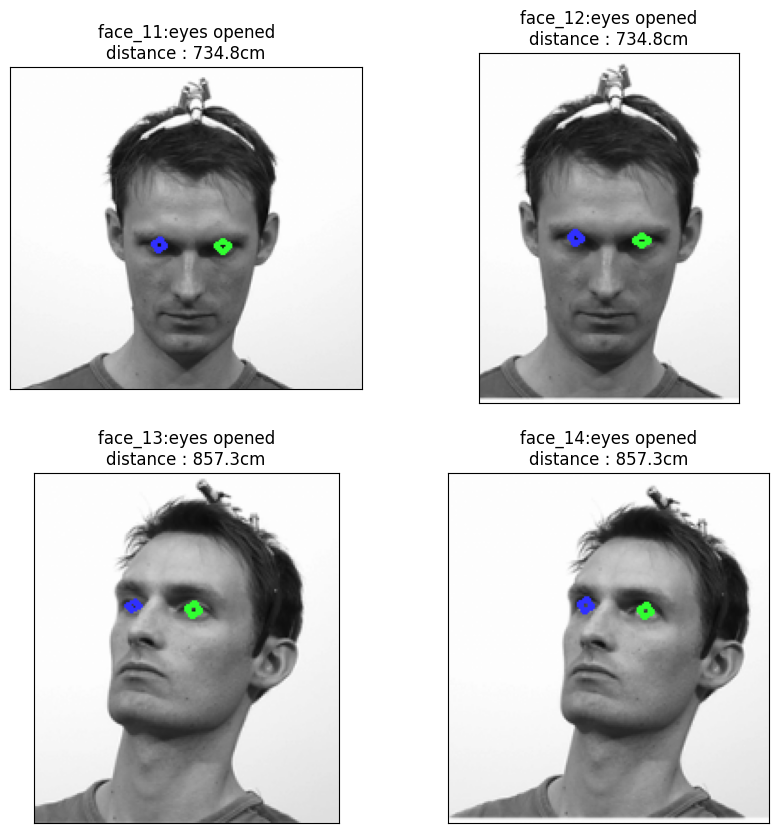

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        img = sorted_list[9+2*i+j]
        landmark_image, b, d = make_IRIS_image(img)
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}:{b}\ndistance : {np.round(d/10, 1)}cm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

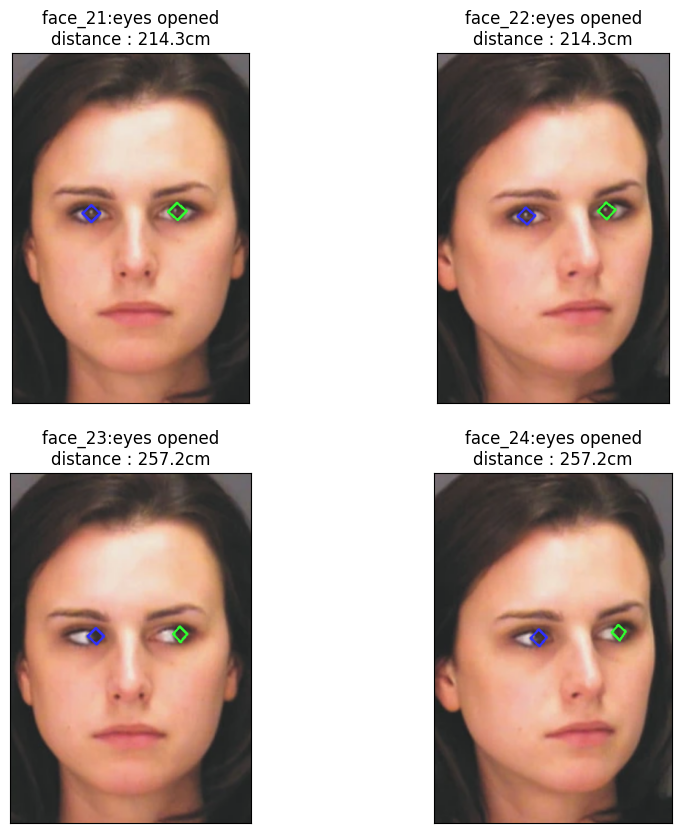

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    for j in range(2):
        img = sorted_list[13+2*i+j]
        landmark_image, b, d = make_IRIS_image(img)
        axes[i, j].imshow(landmark_image)
        axes[i, j].set_title(f"{img.split('/')[-1].split('.')[0]}:{b}\ndistance : {np.round(d/10, 1)}cm")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.show()

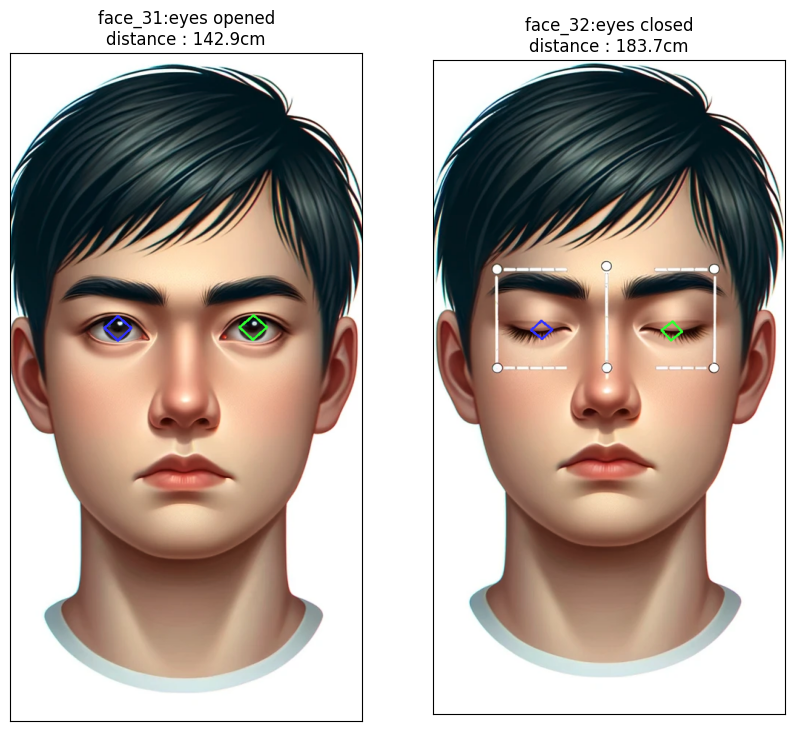

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
img = sorted_list[17]
landmark_image, b, d = make_IRIS_image(img)
axes[0].imshow(landmark_image)
axes[0].set_title(f"{img.split('/')[-1].split('.')[0]}:{b}\ndistance : {np.round(d/10, 1)}cm")
axes[0].set_xticks([])
axes[0].set_yticks([])

img = sorted_list[18]
landmark_image, b, d = make_IRIS_image(img)
axes[1].imshow(landmark_image)
axes[1].set_title(f"{img.split('/')[-1].split('.')[0]}:{b}\ndistance : {np.round(d/10, 1)}cm")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.show()

### 2.2 Iris Ellipse Fitting

**Goal:** Determine the ellipse parameters (center, orientation angle) of the iris.

**Method 1:** Compute semi-major and semi-minor axes from the iris landmarks, then fit an ellipse.

In [ ]:
def find_iris_parameter(image_path):
    image = mp.Image.create_from_file(image_path)
    detection_result = detector.detect(image)
    rightEyeIris = detection_result.face_landmarks[0][473:]
    leftEyeIris = detection_result.face_landmarks[0][468:473]

    x_shape = image.numpy_view().shape[1]
    y_shape = image.numpy_view().shape[0]

    for landmark in rightEyeIris:
        landmark.x *= x_shape
        landmark.y *= y_shape
    for landmark in leftEyeIris:
        landmark.x *= x_shape
        landmark.y *= y_shape

    # Right eye: compute center as mean of peripheral landmarks
    sum_x = sum(landmark.x for landmark in rightEyeIris[1:])
    sum_y = sum(landmark.y for landmark in rightEyeIris[1:])
    approx_right_center = (sum_x / len(rightEyeIris[1:]), sum_y / len(rightEyeIris[1:]))

    # Left eye: compute center as mean of peripheral landmarks
    sum_x = sum(landmark.x for landmark in leftEyeIris[1:])
    sum_y = sum(landmark.y for landmark in leftEyeIris[1:])
    approx_left_center = (sum_x / len(leftEyeIris[1:]), sum_y / len(leftEyeIris[1:]))

    # Right eye: major/minor axes and orientation
    right_axis = [abs(rightEyeIris[1].x - approx_right_center[0]),
                  abs(rightEyeIris[2].y - approx_right_center[1])]
    right_major_angle_candi = np.argmax(right_axis)
    right_major = max(right_axis)
    right_minor = min(right_axis)

    # Left eye: major/minor axes and orientation
    left_axis = [abs(leftEyeIris[1].x - approx_left_center[0]),
                 abs(leftEyeIris[2].y - approx_left_center[1])]
    left_major_angle_candi = np.argmax(left_axis)
    left_major = max(left_axis)
    left_minor = min(left_axis)

    if right_major_angle_candi == 0:
        right_angle = math.atan2(rightEyeIris[1].y - approx_right_center[1],
                                 rightEyeIris[1].x - approx_right_center[0])
    else:
        right_angle = math.atan2(rightEyeIris[2].y - approx_right_center[1],
                                 rightEyeIris[2].x - approx_right_center[0])

    if left_major_angle_candi == 0:
        left_angle = math.atan2(leftEyeIris[1].y - approx_left_center[1],
                                leftEyeIris[1].x - approx_left_center[0])
    else:
        left_angle = math.atan2(leftEyeIris[2].y - approx_left_center[1],
                                leftEyeIris[2].x - approx_left_center[0])

    return ((approx_right_center, right_major, right_minor, right_angle),
            (approx_left_center, left_major, left_minor, left_angle))

In [ ]:
num = 0
center, major, minor, theta = find_iris_parameter(sorted_list[num])[0]
print(f"Center of the ellipse: (x0, y0) = ({center[0]:.2f}, {center[1]:.2f})")
print(f"Orientation angle (radians): {theta}")

/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Center of the ellipse: (x0, y0) = (224.08, 144.50)
Orientation angle (in radian): -0.06440334402354053


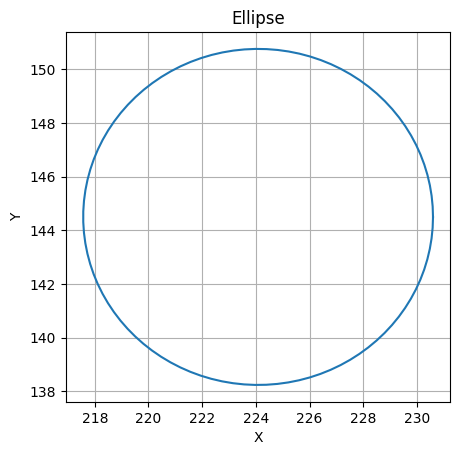

In [161]:
angle = theta
theta0 = np.linspace(0, 2 * np.pi, 100)

# Parametric ellipse coordinates
x = center[0] + major * np.cos(np.radians(angle)) * np.cos(theta0) - minor * np.sin(np.radians(angle)) * np.sin(theta0)
y = center[1] + major * np.sin(np.radians(angle)) * np.cos(theta0) + minor * np.cos(np.radians(angle)) * np.sin(theta0)

plt.figure()
plt.plot(x, y)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Fitted Iris Ellipse')
plt.grid(True)
plt.show()

#### Verification: Overlay Fitted Ellipse on Image

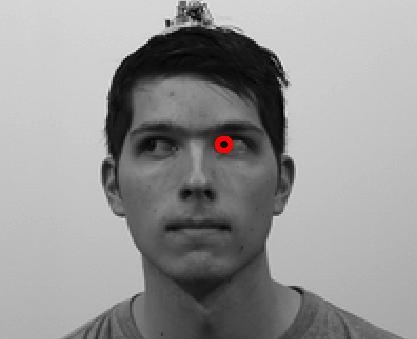

In [191]:
image = mp.Image.create_from_file(sorted_list[num])
detection_result = detector.detect(image)
if detection_result.face_blendshapes != []:
    EyeIRIS = detection_result.face_landmarks[0][468:]
    img = Image.open(sorted_list[num])
    draw = ImageDraw.Draw(img)
    points = [(x1, y1) for x1, y1 in zip(x, y)]
    for point in points:
        radius = 2
        draw.ellipse((point[0]-radius, point[1]-radius, point[0]+radius, point[1]+radius), fill='red')

img

#### General Ellipse Equation

\begin{aligned}
A &= a^{2}\sin^{2}\theta + b^{2}\cos^{2}\theta &
B &= 2(b^{2} - a^{2})\sin\theta\cos\theta \\
C &= a^{2}\cos^{2}\theta + b^{2}\sin^{2}\theta &
D &= -2Ax_{0} - By_{0} \\
E &= -Bx_{0} - 2Cy_{0} &
F &= Ax_{0}^{2} + Bx_{0}y_{0} + Cy_{0}^{2} - a^{2}b^{2}
\end{aligned}

Where $(x_0, y_0)$ is the center, $a$ is the semi-major axis, $b$ is the semi-minor axis, and $\theta$ is the orientation angle.

In [ ]:
def ellips_fitting(center, major, minor, theta):
    a, b = major, minor
    x0, y0 = center[0], center[1]

    A = (a**2) * (np.sin(theta)**2) + (b**2) * (np.cos(theta)**2)
    B = 2 * (b**2 - a**2) * np.sin(theta) * np.cos(theta)
    C = (a**2) * (np.cos(theta)**2) + (b**2) * (np.sin(theta)**2)
    D = -2 * A * x0 - B * y0
    E = -B * x0 - 2 * C * y0
    F = A * x0**2 + B * x0 * y0 + C * y0**2 - a**2 * b**2

    print("Ellipse coefficients:")
    print(f"  A={A}, B={B}, C={C}, D={D}, E={E}, F={F}")
    return A, B, C, D, E, F

(A, B, C, D, E, F) = ellips_fitting(center, major, minor, theta)

Coefficients of the ellipse:
A = 269.02446705341845
B = 0.9301756731819675
C = 334.4243314075849
D = -176750.3706959541
E = -249121.4929386474
F = 75222152.93766151


#### Comparison: Parametric Ellipse vs. Equation-Based Ellipse

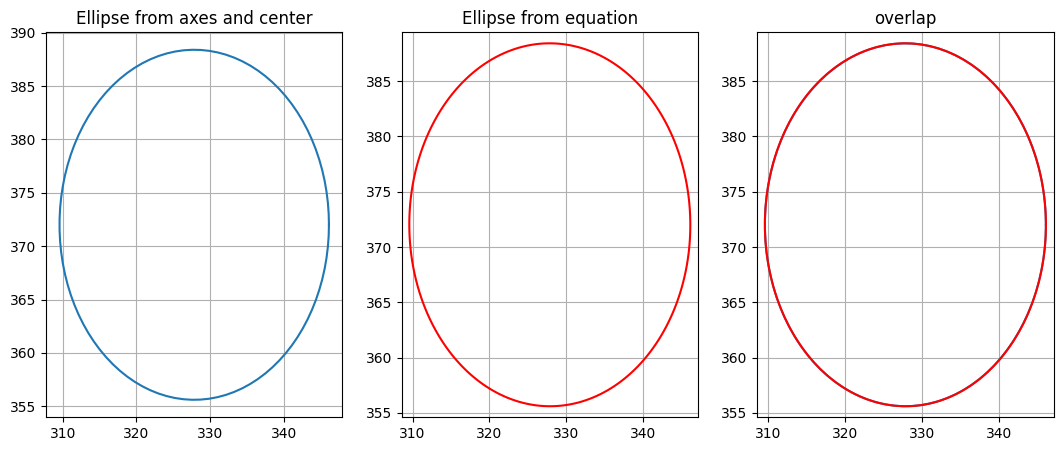

In [32]:
def ellipse_eq(x, y):
    return A*x**2 + B*x*y + C*y**2 + D*x + E*y + F

x0 = np.linspace(min(x)-1, max(x)+1, 100)
y0 = np.linspace(min(y)-1, max(y)+1, 100)
X, Y = np.meshgrid(x0, y0)
Z = ellipse_eq(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(x, y)
axes[0].set_title('Ellipse from axes and center')
axes[0].grid(True)

axes[1].contour(X, Y, Z, levels=[0], colors='r')
axes[1].set_title('Ellipse from equation')
axes[1].grid(True)

axes[2].plot(x, y)
axes[2].contour(X, Y, Z, levels=[0], colors='r')
axes[2].set_title('Overlap')
axes[2].grid(True)
plt.show()

### 2.3 Ellipse Fitting via SVD

**Method 2:** Add estimated boundary points to the 4 iris landmarks (6 points needed for the general conic equation $Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0$), then solve via SVD.

Since we have only 4 landmark points on the curve, we need at least 2 additional estimated points. The system is overdetermined, so we find the least-squares solution using SVD.

Given the system $M\mathbf{x} = \mathbf{0}$, where $M$ is the design matrix:

\begin{aligned}
\begin{bmatrix}
x_1^2 & x_1 y_1 & y_1^2 & x_1 & y_1 & 1 \\
x_2^2 & x_2 y_2 & y_2^2 & x_2 & y_2 & 1 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
x_n^2 & x_n y_n & y_n^2 & x_n & y_n & 1
\end{bmatrix}
\begin{bmatrix} A \\ B \\ C \\ D \\ E \\ F \end{bmatrix}
= \mathbf{0}
\end{aligned}

We decompose $M = U \Sigma V^T$ and take the last row of $V^T$ (corresponding to the smallest singular value) as the solution.

In [ ]:
def approx_ellips(img, x_shift=0.01, y_shift=0.265):
    image = mp.Image.create_from_file(img)
    detection_result = detector.detect(image)
    rightEyeIris = detection_result.face_landmarks[0][473:]

    x_shape = image.numpy_view().shape[1]
    y_shape = image.numpy_view().shape[0]

    for landmark in rightEyeIris:
        landmark.x *= x_shape
        landmark.y *= y_shape

    points = np.array([(landmark.x, landmark.y) for landmark in rightEyeIris[1:]])

    # Add 2 estimated boundary points
    additional_points = np.array([
        [points[0][0] - x_shift, points[0][1] + y_shift],
        [points[0][0] - x_shift, points[0][1] - y_shift]
    ])
    matrix = np.vstack((points, additional_points))

    # Build design matrix and solve via SVD
    matrix = np.array([[x**2, x*y, y**2, x, y, 1] for x, y in matrix])
    u, s, vh = np.linalg.svd(matrix)
    solution = vh[-1, :]
    A, B, C, D, E, F = solution

    # Compute center
    denominator = B**2 - 4*A*C
    if denominator == 0:
        print("This is not an ellipse.")
    else:
        x0 = (2*C*D - B*E) / denominator
        y0 = (2*A*E - B*D) / denominator
        print(f"Center of the ellipse: (x0, y0) = ({x0:.2f}, {y0:.2f})")

    theta = 0.5 * np.arctan(B / (A - C))
    print(f"Orientation angle (radians): {theta}")
    return A, B, C, D, E, F

(A, B, C, D, E, F) = approx_ellips(sorted_list[num])

Center of the ellipse: (x0, y0) = (327.96, 372.19)
Orientation angle (in radian): -0.10285582246789268


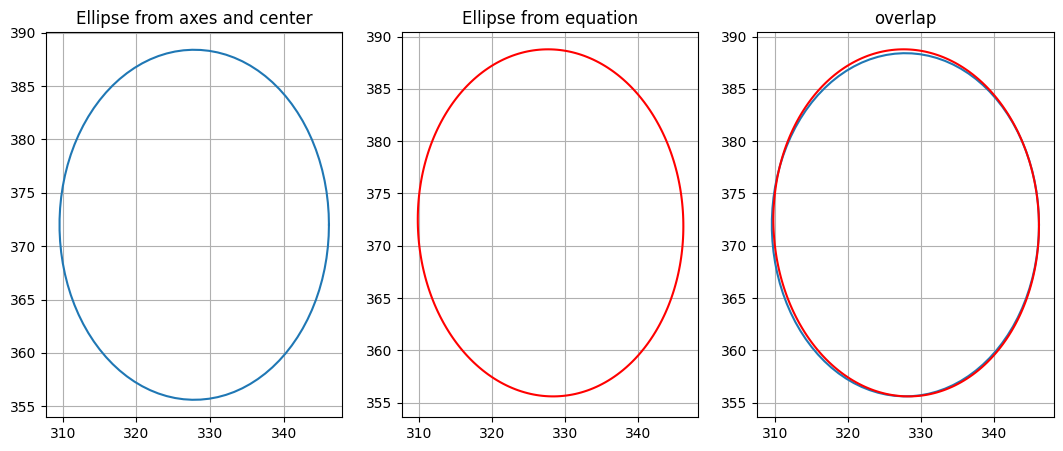

In [35]:
def ellipse_eq(x, y):
    return A*x**2 + B*x*y + C*y**2 + D*x + E*y + F

x0 = np.linspace(min(x)-2, max(x)+2, 100)
y0 = np.linspace(min(y)-2, max(y)+2, 100)
X, Y = np.meshgrid(x0, y0)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(x, y)
axes[0].set_title('Ellipse from axes and center')
axes[0].grid(True)

Z = ellipse_eq(X, Y)
axes[1].contour(X, Y, Z, levels=[0], colors='r')
axes[1].set_title('Ellipse from SVD')
axes[1].grid(True)

axes[2].plot(x, y)
axes[2].contour(X, Y, Z, levels=[0], colors='r')
axes[2].set_title('Overlap')
axes[2].grid(True)
plt.show()